<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/entropy.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>


(entropy_notebook)=
# Entropia

In questo capitolo, esploreremo il concetto di entropia, sottolineando il suo ruolo fondamentale nel processo di quantificazione dell'incertezza all'interno delle distribuzioni di probabilità. Inoltre, affronteremo il tema cruciale di come l'entropia possa essere utilizzata per valutare la "distanza" tra un modello teorico e i dati osservati. A tale scopo, introdurremo la divergenza di Kullback-Leibler (KL), una misura che non solo misura le discrepanze tra due distribuzioni probabilistiche, ma offre anche una prospettiva approfondita sulla valutazione della concordanza tra teoria e realtà empirica.

## Preparazione del Notebook

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics import tsaplots
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-grayscale")
from cycler import cycler
default_cycler = cycler(color=["#000000", "#6a6a6a", "#bebebe", "#2a2eec"])
plt.rc('axes', prop_cycle=default_cycler)

## La Generalizzabilità dei Modelli e il Metodo Scientifico

La generalizzabilità dei modelli è un concetto chiave nella scienza, essendo uno dei fondamenti del metodo scientifico. Questo principio si riferisce alla capacità di un modello di applicarsi e produrre risultati validi oltre il contesto specifico o il set di dati in cui è stato originariamente sviluppato o testato. Il valore scientifico di un modello è quindi significativamente influenzato dalla sua capacità di generalizzarsi a nuovi dati.

Un aspetto critico della valutazione della generalizzabilità di un modello è la sua replicabilità, che, sebbene necessaria, non è di per sé sufficiente a garantire la generalizzabilità. Un modello può replicare fedelmente i risultati in studi simili, ma ciò non implica automaticamente che possa applicarsi correttamente a contesti o dati diversi. Questa distinzione sottolinea l'importanza di esaminare attentamente le basi su cui un modello è costruito e la sua applicabilità oltre le condizioni originali di test.

Per valutare efficacemente la robustezza e la generalizzabilità di un modello, si dovrebbero considerare tre domande fondamentali {cite:p}`Johnson2022bayesrules`:

1. Quali sono le implicazioni delle nostre inferenze basate sul modello?
2. Le assunzioni su cui si basa il modello sono valide in contesti diversi da quelli testati?
3. Quanto accuratamente il modello può fare previsioni su nuovi dati non ancora osservati?

Queste domande sono essenziali per determinare se un modello può essere considerato generalizzabile, enfatizzando l'importanza di costruire modelli capaci di fare previsioni precise su dati nuovi.

Nella pratica, la generalizzabilità di un modello può essere minacciata da due problemi principali: il sotto-adattamento e il sovra-adattamento. Il sotto-adattamento si verifica quando un modello è troppo semplice per catturare adeguatamente la complessità dei dati, portando a prestazioni insoddisfacenti sia sui dati di addestramento che su nuovi insiemi di dati. Questo limita gravemente la sua utilità in applicazioni pratiche. Al contrario, il sovra-adattamento si manifesta quando un modello è eccessivamente complesso, adattandosi troppo fedelmente al rumore o alle peculiarità specifiche del set di dati di addestramento a discapito della capacità di generalizzare a nuovi dati.

L'approccio bayesiano alla modellazione offre una via d'uscita da questi problemi, permettendo di quantificare in modo efficace l'incertezza e di migliorare la capacità predittiva di un modello attraverso la gestione del compromesso tra complessità del modello e adattamento ai dati.

La selezione dei modelli, come sottolineato da {cite:t}`McElreath_rethinking`, richiede un equilibrio tra semplicità e capacità di catturare accuratamente la realtà dei dati. Il principio del rasoio di Ockham, che predilige le spiegazioni più semplici quando sono disponibili più spiegazioni equivalenti per un fenomeno, è spesso utilizzato per guidare questa selezione. Tuttavia, è cruciale anche assicurarsi che il modello descriva i dati in modo accurato. L'uso dei valori-p per la selezione dei modelli, sebbene comune, è criticato per la mancanza di una qualsiasi giustificazione {cite:p}`McElreath_rethinking`. 

Invece, un approccio più robusto e scientificamente fondato per la selezione del modello coinvolge l'uso della divergenza di Kullback-Leibler. Questa misura valuta quanto un modello sia "vicino" alla distribuzione reale dei dati, fornendo una stima quantitativa della sua aderenza al processo generativo sottostante. Nel capitolo successivo discuteremo l'uso della divergenza di Kullback-Leibler. Prima, però, è necessario chiarire il concetto di entropia. Questo è l'obiettivo del capitolo presente.

## Entropia: Una Misura dell'Incertezza

Nel contesto dell'informatica e della teoria della probabilità, l'entropia è un concetto fondamentale che è stato introdotto da Claude Shannon durante il suo lavoro presso i Bell Labs. L'entropia quantifica la sorpresa che si sperimenta nell'osservare un determinato evento. Shannon, nel cercare di misurare questa incertezza, stabilì tre criteri chiave che qualsiasi metrica dovrebbe soddisfare: dovrebbe essere continua, dovrebbe aumentare al crescere della quantità di informazione, e dovrebbe essere additiva. Questi requisiti conducono alla definizione dell'entropia dell'informazione.

L'entropia dell'informazione, secondo Shannon, misura il valore informativo medio presente in un messaggio o, detto in altro modo, quantifica quanto l'incertezza iniziale viene ridotta dopo aver ricevuto il messaggio. Ad esempio, se ci viene rivelato che un evento con probabilità $ p $ si è verificato, la sorpresa che ne deriva viene quantificata da $ -\log_2(p) $, dove il risultato è espresso in bit. Questa formulazione implica che gli eventi più improbabili, aventi bassa probabilità, comportano una maggiore sorpresa, mentre gli eventi certi (con probabilità 1) non ne comportano alcuna. Il logaritmo in base 2 viene utilizzato perché, nel campo dell'informatica, il bit rappresenta l'unità di misura fondamentale dell'informazione, corrispondente alla scelta tra due possibilità equiprobabili.

Nel caso di due eventi indipendenti $ A $ e $ B $, la sorpresa totale derivante dall'osservazione di entrambi gli eventi, $ A \cap B $, è uguale alla somma delle sorprese di ciascun evento singolarmente. Questo è dovuto alla proprietà additiva dei logaritmi.

Considerando una variabile casuale discreta $ X $ che può assumere valori $ a_1, a_2, \ldots, a_n $ con probabilità associate $ p_1, p_2, \ldots, p_n $, dove la somma delle probabilità è uguale a 1, l'entropia di $ X $ si calcola come la media ponderata delle sorprese per ogni possibile esito:

$$
H(X) = -\sum_{i=1}^{n} p_i \log_2 p_i,
$$

dove $ p_i $ è la probabilità di osservare l'esito $ i $-esimo. Questa formula rappresenta l'ammontare medio di informazione, o sorpresa, che ci si aspetta di ottenere dall'osservazione di $ X $.

Per variabili con distribuzioni continue, l'entropia si estende in modo analogo:

$$
H(X) = -\int p(x) \log_2 p(x) \, dx,
$$

dove l'integrale si estende su tutti i possibili esiti di $ X $. 

L'entropia raggiunge il suo valore massimo in situazioni di completa incertezza, ossia quando ogni esito possibile ha la stessa probabilità di verificarsi, segnalando il massimo grado di variabilità o imprevedibilità. In contrasto, l'entropia è minima, pari a zero, quando l'esito di un evento è completamente determinato, evidenziando assenza di incertezza. Questa misura è cruciale nella teoria dell'informazione, offrendo un mezzo quantitativo per comprendere, valutare e gestire l'incertezza nei sistemi di comunicazione e nei dati.

```{note}
Il segno meno (-) nell'equazione dell'entropia $ H(X) = -\sum_{i=1}^{n} p_i \log_2 p_i $ serve a garantire che l'entropia sia una quantità non negativa. Questa scelta è motivata dalla natura del logaritmo di una probabilità, che diventa negativo quando la probabilità $ p_i $ è compresa tra 0 e 1.

Per comprendere meglio, consideriamo il funzionamento del logaritmo in base 2 ($ \log_2 $) di una probabilità $ p $:

- Quando $ p $ è esattamente 1 (evento certo), $ \log_2(1) = 0 $. Non c'è sorpresa nell'osservare un evento che sappiamo accadrà sempre, quindi l'entropia in questo caso dovrebbe essere 0, indicando assenza di incertezza.
- Quando $ p $ è minore di 1 (evento incerto), il logaritmo $ \log_2(p) $ diventa negativo, poiché stiamo prendendo il logaritmo di un numero frazionario (es. $ \log_2(0.5) = -1 $). Questo riflette l'idea che c'è una certa "sorpresa" o incertezza quando si osserva un evento non certo.

Il segno meno viene quindi introdotto per trasformare questo valore negativo in positivo, in linea con l'interpretazione dell'entropia come misura dell'incertezza o della quantità di informazione: maggiore è l'incertezza su quale evento si verificherà, maggiore sarà l'entropia. In questo modo, l'entropia, essendo una somma di termini positivi, risulta sempre una quantità non negativa. Questo trattamento garantisce che l'entropia sia coerente con la sua interpretazione come misura di incertezza: un valore di entropia maggiore indica una maggiore incertezza (o variabilità) nella distribuzione di probabilità di una variabile casuale.
```

## Esempi concreti per l'Entropia

Per comprendere meglio il concetto di entropia, esaminiamo alcuni esempi pratici.

### L'Entropia di un Singolo Evento

Prendiamo in considerazione il lancio di una moneta equilibrata. In questo caso, la probabilità di ottenere testa (così come croce) è di 0.5. La quantità di informazione, o sorpresa, risultante dall'ottenimento di "testa" in un tale esperimento è calcolata mediante la formula dell'entropia:

$$
H(\text{Testa}) = -\log_2(0.5).
$$

In [3]:
-np.log2(0.5)

1.0

Calcolando il logaritmo in base 2 di 0.5, otteniamo un valore di 1 bit. Questo significa che, in termini di entropia, ogni risultato del lancio di una moneta (sia testa che croce) contribuisce con un bit di informazione. Questo riflette l'incertezza massima in un processo con due esiti equiprobabili: ogni lancio di una moneta equilibrata è completamente imprevedibile e, di conseguenza, fornisce la massima quantità di informazione possibile.

In questo contesto, dove tutti gli esiti sono equiprobabili, l'entropia raggiunge il suo valore massimo, indicando un'incertezza totale sul risultato prima del lancio. La sorpresa, o informazione acquisita, osservando il risultato è quindi massima. 

Al contrario, se consideriamo un evento con una probabilità di 1 (per esempio, una moneta truccata che produce sempre "Testa"), l'entropia è $ H(p = 1) = 0 $. Questo implica che l'osservazione dell'esito "Testa" non fornisce alcuna informazione aggiuntiva, in quanto l'evento è prevedibile con certezza.

Se si effettuano $ n $ lanci di una moneta equilibrata, ogni lancio contribuisce con 1 bit all'informazione totale. Pertanto, una sequenza di $ n $ lanci richiede $ n $ bit di informazione per essere descritta completamente.

Consideriamo ora una moneta sbilanciata, dove la probabilità di ottenere "Testa" è solo del 10% (0.1). In questo caso, l'evento "Testa" diventa più raro e, quindi, sorprendente quando si verifica. L'entropia per l'evento "Testa" in questa situazione è calcolata come:

$$
H(\text{Testa}) = -\log_2(0.1).
$$

Calcolando questo logaritmo, otteniamo un valore superiore a 3 bit. 

In [4]:
-np.log2(0.1)

3.321928094887362

Questo significa che l'informazione necessaria per rappresentare adeguatamente l'evento "Testa" in una moneta sbilanciata è maggiore rispetto a una moneta equilibrata. La maggiore rarità dell'evento aumenta la sorpresa e, di conseguenza, l'informazione associata alla sua osservazione.

Consideriamo ora il caso di un dado a sei facce e concentriamoci sull'evento "uscita del numero 6". La probabilità di questo evento è di 1/6, inferiore rispetto alla probabilità di 1/2 di ottenere "testa" con un lancio di moneta. Conseguentemente, ci aspettiamo che l'evento "uscita del numero 6" generi una sorpresa maggiore rispetto all'evento "testa" in un lancio di moneta. 

Per quantificare l'informazione associata all'evento "uscita del numero 6", possiamo utilizzare la formula dell'informazione di Shannon:

$$
-\log_2\left(\frac{1}{6}\right) \approx 2.58 \text{ bit}.
$$

In [5]:
-np.log2(1/6)

2.584962500721156

Questo calcolo mostra che l'informazione associata all'uscita del numero 6 è di circa 2.58 bit, significativamente superiore all'informazione di 1 bit per l'evento "testa". In pratica, ciò significa che l'evento legato al dado è più "sorprendente" e porta con sé più informazione rispetto all'evento del lancio di moneta.

### Informazione di Shannon e Entropia: Differenze e Relazioni

L'informazione di Shannon e l'entropia sono due concetti strettamente correlati ma con alcune distinzioni chiave. La principale differenza tra i due concetti è che l'informazione di Shannon si concentra su un singolo evento, mentre l'entropia considera la distribuzione di probabilità complessiva di una variabile aleatoria.

L'informazione di Shannon $ I(x) $ è definita come la quantità di informazione contenuta in un singolo evento $ x $, in base alla sua probabilità $ p(x) $. La formula è:

$$
I(x) = -\log_{2}(p(x)).
$$

L'informazione è tanto maggiore quanto più bassa è la probabilità dell'evento (ovvero, gli eventi rari sono più "sorprendenti") e diminuisce all'aumentare della probabilità dell'evento.

D'altro canto, l'entropia $ H(X) $ rappresenta l'incertezza media associata a una variabile aleatoria $ X $, considerando la sua distribuzione di probabilità $ p(x) $. Viene calcolata come l'aspettazione matematica dell'informazione di Shannon per tutti i possibili esiti $ x $ di $ X $:

$$
H(X) = \mathbb{E}[I(X)] = -\sum_{x \in X} p(x) \log_{2}(p(x)).
$$

In questo modo, l'entropia rappresenta la media ponderata delle informazioni di Shannon per ogni possibile esito di $ X $. Si tratta, in altre parole, di una misura della sorpresa media o dell'informazione attesa osservando la variabile aleatoria $ X $ nel lungo termine.

In sintesi, mentre l'informazione di Shannon ci dice quanto saremmo sorpresi dall'osservare un singolo esito, l'entropia fornisce un'indicazione aggregata della nostra sorpresa media, tenendo conto di tutti gli esiti possibili.

La figura successiva mostra la relazione tra probabilità e informazione, per valori di probabilità nell'intervallo tra 0 e 1.

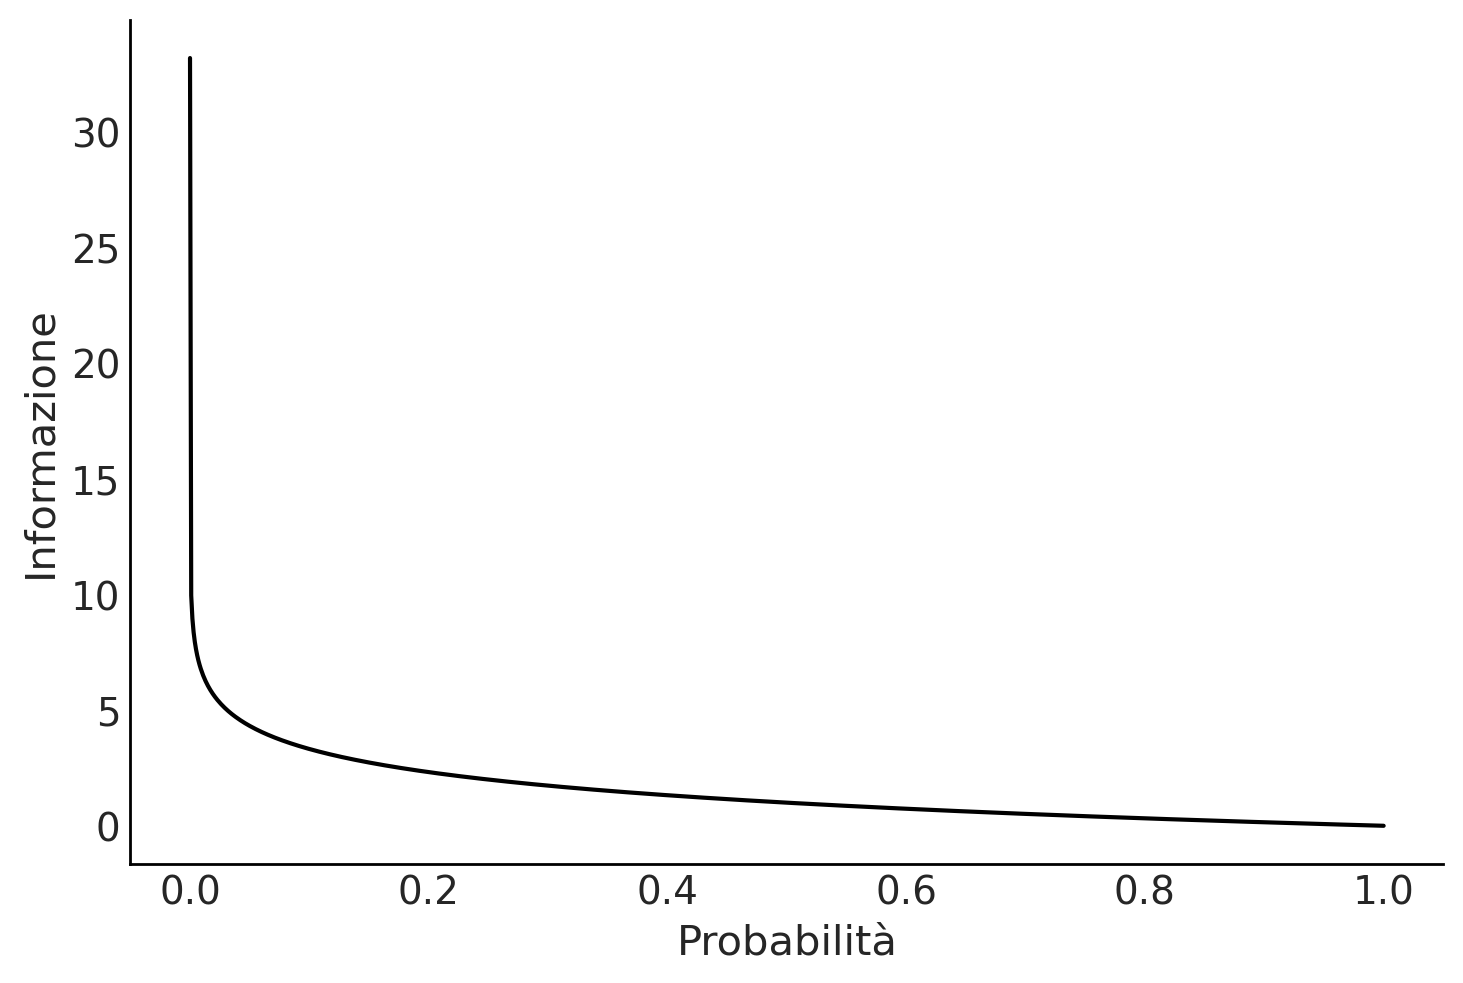

In [6]:
# Create a sequence of 1000 equally spaced points from 0 to 1
p = np.linspace(0, 1, 1000)

# Avoid log(0) by replacing 0 with a small value
p[p == 0] = 1e-10

# Compute the negative log base 2 of p
h = -np.log2(p)

df = pd.DataFrame({'Probabilità': p, 'Informazione': h})

plt.plot('Probabilità', 'Informazione', data=df)
plt.xlabel('Probabilità')
plt.ylabel('Informazione');

La figura mostra che questa relazione non è lineare, è infatti leggermente sublineare. Questo ha senso dato che abbiamo usato una funzione logaritmica.

#### Entropia e Varianza di una Distribuzione

È comune pensare che l'entropia e la varianza di una distribuzione siano collegate in modo tale che, all'aumentare della varianza, aumenti anche l'entropia. Tuttavia, la relazione tra queste due misure non è così diretta e può variare a seconda delle caratteristiche specifiche delle distribuzioni.

Consideriamo, per esempio, il caso di distribuzioni normali con diversi valori di varianza. In Python, possiamo calcolare l'entropia di queste distribuzioni come segue:

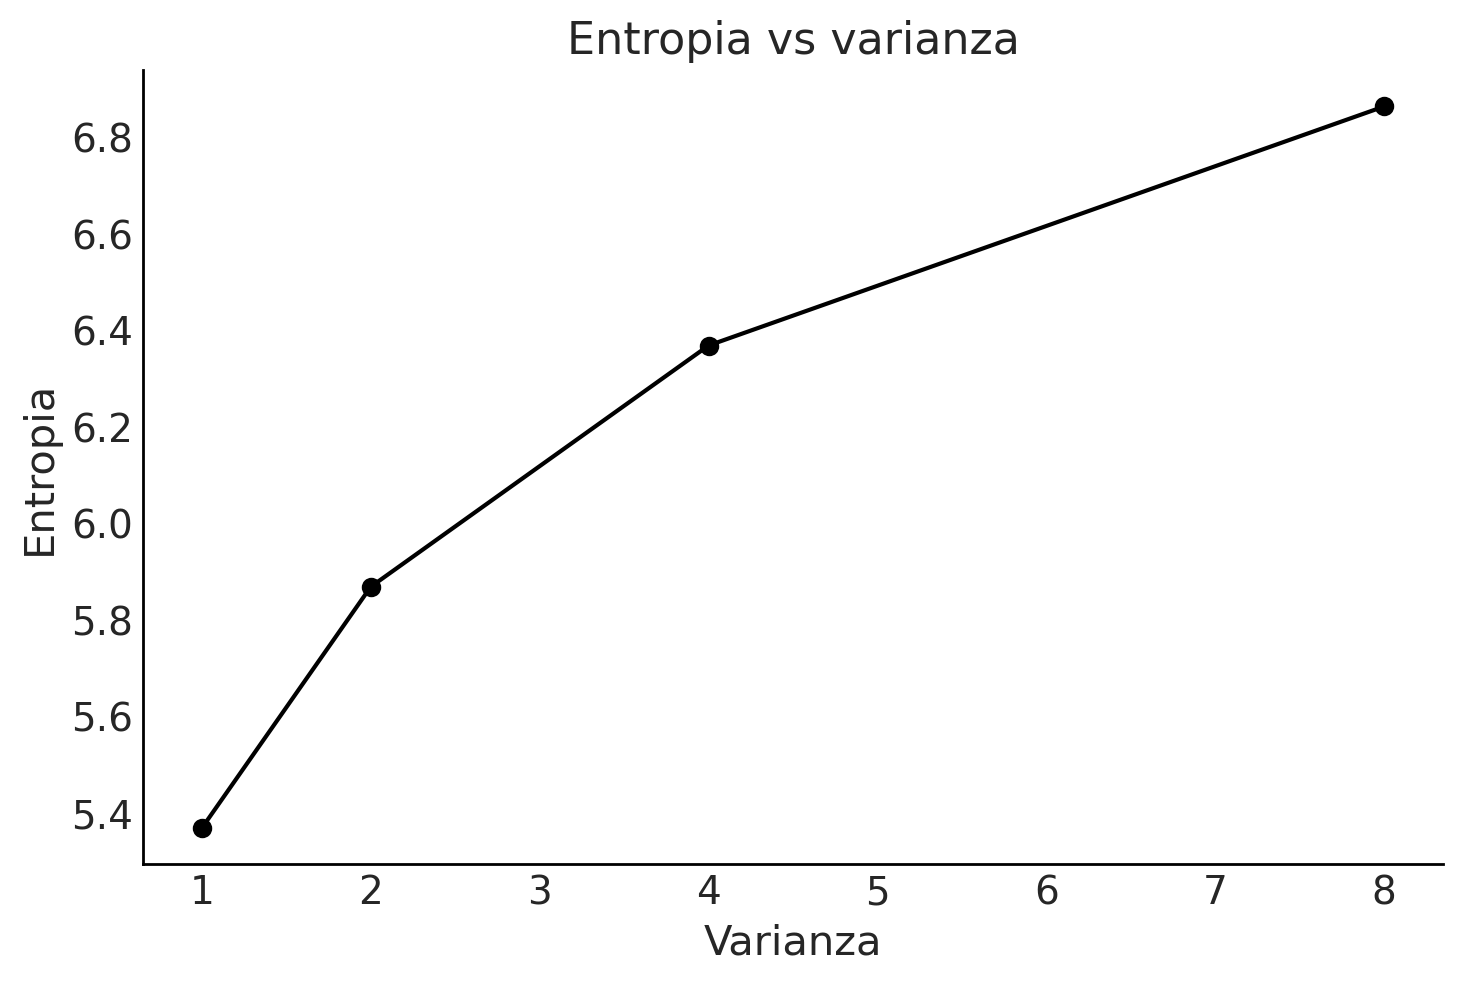

In [7]:
# Intervallo di valori discreti
x = np.arange(-10, 10, 0.1)

def calculate_entropy(variance):
    # Distribuzione normale con media 0 e varianza specifica
    probabilities = stats.norm.pdf(x, 0, np.sqrt(variance))
    
    # Normalizzazione delle probabilità in modo che sommino a 1
    probabilities /= probabilities.sum()
    
    # Calcolo dell'entropia
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

# Varianze da esplorare
variances = [1, 2, 4, 8]

# Calcolo e tracciamento dell'entropia per diverse varianze
entropies = [calculate_entropy(variance) for variance in variances]

plt.plot(variances, entropies, marker='o')
plt.title('Entropia vs varianza')
plt.xlabel('Varianza')
plt.ylabel('Entropia');

Questo script mostra che, per la distribuzione normale, l'entropia tende ad aumentare con l'aumento della varianza. Tuttavia, consideriamo ora due distribuzioni con la stessa varianza ma probabilità differenti:

In [8]:
def calculate_entropy(probabilities):
    return -np.sum(probabilities * np.log2(probabilities))

# Distribuzioni con la stessa varianza ma diverse probabilità
probabilities1 = np.array([0.5, 0.25, 0.25])
probabilities2 = np.array([0.3333, 0.3333, 0.3334])

# Calcolo dell'entropia per entrambe le distribuzioni
entropy1 = calculate_entropy(probabilities1)
entropy2 = calculate_entropy(probabilities2)

print(f"Entropia della distribuzione 1: {entropy1}")
print(f"Entropia della distribuzione 2: {entropy2}")

Entropia della distribuzione 1: 1.5
Entropia della distribuzione 2: 1.5849624862946867


Questo esempio dimostra che due distribuzioni con la stessa varianza possono avere entropie differenti, a seconda della configurazione delle loro probabilità.

In sintesi:

- *Varianza:* Misura la dispersione dei dati intorno alla loro media. Quantifica quanto i valori si discostano dalla media, ma non considera la probabilità di ciascun valore.
- *Entropia:* Valuta l'incertezza nella distribuzione di probabilità. Considera la probabilità di ogni possibile esito, quantificando l'incertezza media nell'osservazione di un esito casuale.

Pertanto, distribuzioni con la stessa varianza possono avere entropie differenti e viceversa. Questo dipende da come sono distribuite le probabilità all'interno della distribuzione. La varianza e l'entropia sono, quindi, indicatori complementari dell'incertezza in una distribuzione di dati, ma esplorano questa incertezza da prospettive diverse.

## Divergenza di Kullback-Leibler: Un Strumento per Confrontare le Distribuzioni

Dopo aver introdotto il concetto di entropia di Shannon, che serve a quantificare l'incertezza o la sorpresa legata all'osservazione di un evento, consideriamo la Divergenza di Kullback-Leibler (KL), proposta da Kullback e Leibler nel 1951. Questa misura non è l'opposto dell'entropia di Shannon, ma piuttosto un'estensione di essa, utilizzata per quantificare quanto una distribuzione di probabilità si discosta da un'altra distribuzione di riferimento.

La divergenza KL tra due distribuzioni, $P$ e $Q$, che descrivono la stessa variabile aleatoria $X$, viene calcolata secondo formule diverse a seconda che le distribuzioni siano discrete o continue. Nel caso di distribuzioni discrete, la formula è:

$$
D_{KL}(P \parallel Q) = \sum_x p(x) \log \left(\frac{p(x)}{q(x)}\right),
$$

mentre per le distribuzioni continue, si usa:

$$
D_{KL}(P \parallel Q) = \int p(x) \log \left(\frac{p(x)}{q(x)}\right) \, dx.
$$

Questa misura è sempre non negativa e rappresenta la quantità di informazione "persa" quando si usa la distribuzione $Q$ per approssimare la distribuzione $P$.

La Divergenza KL può essere inoltre vista in termini di entropia, esprimendola come la differenza tra l'entropia incrociata $H(P, Q)$ e l'entropia $H(P)$ di $P$. L'entropia di $P$ si calcola come:

$$
H(P) = -\sum_x p(x) \log(p(x)),
$$

e l'entropia incrociata tra $P$ e $Q$ è definita da:

$$
H(P, Q) = -\sum_x p(x) \log(q(x)).
$$

Qui, l'entropia $H(P)$ misura l'incertezza intrinseca nella distribuzione $P$, mentre l'entropia incrociata $H(P, Q)$ quantifica l'incertezza che si ottiene quando si utilizza $Q$ per stimare $P$. La Divergenza KL, quindi, evidenzia la discrepanza tra l'incertezza (o sorpresa) media che si avrebbe utilizzando le vere probabilità $p$ e quella basata sulle stime $q$, offrendo una misura quantitativa dell'errore o della distorsione introdotta nell'approssimare una distribuzione di probabilità con un'altra.

In termini pratici, la divergenza KL viene spesso adottata come criterio nella selezione di modelli, cercando un modello $Q$ che minimizzi la divergenza $D_{KL}(P \parallel Q)$, ovvero che riduca al minimo la differenza $H(P, Q) - H(P)$.

È cruciale notare che la divergenza KL è sempre non negativa e raggiunge il valore zero esclusivamente quando $P$ e $Q$ sono perfettamente identiche. Inoltre, la divergenza KL non è simmetrica, significando che $D_{KL}(P \parallel Q)$ non è uguale a $D_{KL}(Q \parallel P)$.

In sintesi, la divergenza di Kullback-Leibler fornisce un metodo quantitativo per valutare l'efficacia con cui una distribuzione $Q$ può approssimare un'altra distribuzione $P$, tenendo conto delle incertezze associate a entrambe le distribuzioni.

### Applicazione nella Selezione di Modelli

Uno degli obiettivi chiave nella selezione di modelli statistici è identificare il modello $Q$ che minimizza la divergenza di Kullback-Leibler (KL) rispetto alla distribuzione "vera" $P$ dei dati. Tuttavia, nella realtà pratica, la distribuzione $P$ è spesso sconosciuta e non direttamente osservabile. Pertanto, si ricorre a criteri approssimativi come il Criterio di Informazione di Akaike (AIC) o il Criterio di Informazione Bayesiano (BIC). Questi criteri forniscono stime surrogate per la minimizzazione della divergenza KL, permettendo una valutazione indiretta dell'adeguatezza del modello.

### Esercizio sulla Divergenza di Kullback-Leibler in un Contesto di Esame

Immaginatevi in un contesto di esame a scelta multipla, dove, invece di selezionare una sola risposta per domanda, dovete assegnare una probabilità di correttezza a ciascuna delle opzioni. Il vostro punteggio per ogni domanda sarà calcolato usando il logaritmo della probabilità assegnata all'opzione corretta. Se la risposta giusta è $A_i$, il vostro punteggio per quella domanda sarà $\log(p_i)$, dove $p_i$ è la probabilità che avete attribuito a $A_i$.

In questo sistema di punteggio, il massimo che potete ottenere per una singola domanda è 0 (assegnando una probabilità del 100% alla risposta corretta), mentre il punteggio minimo è $-\infty$ se assegnate una probabilità di zero alla risposta corretta. Il vostro obiettivo finale è massimizzare il punteggio atteso per l'intero esame.

Dato che non conoscete a priori la risposta corretta a ogni domanda, diventa cruciale utilizzare le vostre "migliori stime personali" delle probabilità. Supponiamo che queste stime siano rappresentate dal vettore $p = [p_1, p_2, \ldots, p_n]$.

Il punteggio atteso, basato su queste stime personali, è dato da:

$$
\text{Punteggio atteso con } p = \sum_{i=1}^{n} p_i \log(p_i).
$$

Considerando l'idea di utilizzare un set alternativo di probabilità $q = [q_1, q_2, \ldots, q_n]$, il punteggio atteso cambierebbe a:

$$
\text{Punteggio atteso con } q = \sum_{i=1}^{n} p_i \log(q_i).
$$

La divergenza di Kullback-Leibler (KL) tra i due set di probabilità $p$ e $q$ è calcolata come:

$$
\Delta = D_{KL}(p \parallel q) = \sum_{i=1}^{n} p_i \log\left(\frac{p_i}{q_i}\right).
$$

Questa divergenza KL, sempre non negativa, misura la differenza tra le stime $p$ e $q$. Si annulla solo se $p = q$, indicando che il punteggio atteso è massimizzato quando si utilizzano le stime personali più accurate, $p$.

In questo scenario, quindi, l'approccio ottimale è utilizzare stime basate sulle informazioni a disposizione. Qualsiasi manipolazione delle stime senza giustificazione basata su nuove informazioni riduce il punteggio atteso. Le vostre migliori stime personali rappresentano la comprensione più accurata che avete del problema. Deviare da queste stime senza validi motivi equivale a compromettere le vostre possibilità di successo.

Inoltre, nel sistema di punteggio basato sul logaritmo delle probabilità, non esiste alcun vantaggio nel tentare di "ingannare" il sistema; ogni tentativo di manipolazione si traduce in una penalizzazione del punteggio atteso. Questo allinea perfettamente con i principi della teoria delle decisioni bayesiane, che premia la trasparenza e l'accuratezza nelle stime probabilistiche.

Nella seguente simulazione abbiamo due gruppi di studenti che rispondono a un esame a scelta multipla di sei domande, ognuna con cinque alternative di risposta. Per il gruppo di studenti "onesti", abbiamo impostato che nel 75% dei casi assegnano la probabilità più alta alla risposta corretta. Per il gruppo di studenti che "imbrogliano", abbiamo assunto che riescano a indovinare la risposta corretta nel 60% dei casi, ma assegnano le probabilità in modo distorto.

In [9]:
# Numero di studenti per gruppo
num_studenti = 100
num_domande = 6
num_alternative = 5

# Funzione per calcolare il punteggio atteso usando la metrica del logaritmo delle probabilità
def calcola_punteggio(probabilita):
    return np.sum(probabilita * np.log(probabilita), axis=2)

# Creazione di risposte per il gruppo di studenti onesti (75% di risposte corrette)
p_onesti = np.full((num_studenti, num_domande, num_alternative), 1 / num_alternative)
for studente in range(num_studenti):
    for domanda in range(num_domande):
        if (
            np.random.rand() < 0.75
        ):  # 75% di possibilità di scegliere la risposta corretta
            risposta_corretta = np.random.randint(num_alternative)
            p_onesti[
                studente, domanda, :
            ] = 0.1  # probabilità di base per le risposte sbagliate
            p_onesti[
                studente, domanda, risposta_corretta
            ] = 0.6  # probabilità più alta per la risposta corretta
        # Altrimenti lascia le probabilità uguali (caso in cui la risposta è sbagliata)

# Creazione di risposte per il gruppo di studenti che "imbrogliano" (60% di risposte corrette)
p_imbrogli = np.random.rand(num_studenti, num_domande, num_alternative)
for studente in range(num_studenti):
    for domanda in range(num_domande):
        if (
            np.random.rand() < 0.60
        ):  # 60% di possibilità di scegliere la risposta corretta
            risposta_corretta = np.random.randint(num_alternative)
            p_imbrogli[
                studente, domanda, risposta_corretta
            ] += 5  # aumentare la probabilità per la risposta corretta
        # Distribuzione distorta di probabilità
        p_imbrogli[studente, domanda, :] /= p_imbrogli[studente, domanda, :].sum()

# Calcolo del punteggio atteso per i due gruppi di soggetti
punteggio_onesti = calcola_punteggio(p_onesti)
punteggio_imbrogli = calcola_punteggio(p_imbrogli)

# Calcolo della differenza media dei punteggi tra i due gruppi
differenza_media_onesti_imbrogli = np.mean(punteggio_onesti - punteggio_imbrogli)

differenza_media_onesti_imbrogli

-0.1987046913151248

La differenza media dei punteggi attesi tra i due gruppi, calcolata usando la metrica del logaritmo delle probabilità, è di circa -0.2. Questo risultato suggerisce che, in media, i soggetti che "imbrogliano" (assegnando le probabilità in modo distorto) hanno ottenuto punteggi attesi inferiori rispetto a quelli che hanno assegnato le probabilità in modo più accurato e onesto.

Questo dimostra che, nel contesto di questo esame a scelta multipla, un approccio accurato e onesto nella stima delle probabilità porta a un punteggio atteso più alto, mentre la manipolazione delle stime probabilistiche senza basi informative solide porta a una penalizzazione nel punteggio atteso.​

Calcoliamo ora la divergenza di Kullback-Leibler (KL). 

In [10]:
# Calcolo della divergenza di Kullback-Leibler tra i due gruppi di studenti

def calcola_divergenza_kl(p, q):
    return np.sum(p * np.log(p / q), axis=2)

# Calcolo della divergenza KL per ogni studente e ogni domanda
divergenza_kl = calcola_divergenza_kl(p_onesti, p_imbrogli)

# Calcolo della media della divergenza KL tra tutti gli studenti
media_divergenza_kl = np.mean(divergenza_kl)

media_divergenza_kl

0.9307657326095

La divergenza di KL media calcolata tra i due gruppi di studenti è di circa 0.9.

Nel contesto dell'esercizio, la divergenza KL misura la differenza, su scala logaritmica, tra due approcci di stima delle probabilità rispetto a una distribuzione di probabilità "vera" (che idealmente assegna una probabilità di 1 alla risposta corretta e 0 a tutte le altre).

La divergenza KL di circa 0.9 indica quanto la stima media fornita dal gruppo che "imbroglia" sia più distante dalla distribuzione vera rispetto alla stima media fornita dal gruppo "onesto". In altre parole, un valore di divergenza KL di circa 0.9 indica che le stime dei rispondenti che "imbrogliano" sono in media più lontane dalla distribuzione vera rispetto a quelle dei rispondenti "onesti".


## Riflessioni Conclusive

In questo capitolo, abbiamo esaminato il concetto di entropia, evidenziando il suo ruolo fondamentale nel quantificare l'incertezza all'interno delle distribuzioni di probabilità. Abbiamo anche affrontato la questione di come l'entropia possa essere impiegata per valutare la "distanza" tra un modello teorico e i dati reali. A tale scopo, abbiamo introdotto la divergenza di Kullback-Leibler (KL), una misura che non solo quantifica le discrepanze tra due distribuzioni probabilistiche, ma agisce anche come collegamento tra teoria e pratica, tra il modello ideale e il mondo empirico.

Nel capitolo successivo, approfondiremo ulteriormente il tema della divergenza KL. Esploreremo come questo strumento possa essere utilizzato per confrontare modelli teorici con dati empirici e ci concentreremo su come possa fornirci una comprensione più dettagliata dell'adattamento di un modello alla realtà che intende rappresentare. Questa esplorazione ci permetterà di valutare più accuratamente la validità e la generalizzabilità dei modelli scientifici nel loro tentativo di catturare e interpretare la complessità dei dati reali.

In [11]:
%load_ext watermark
%watermark -n -u -v -iv -w -m

Last updated: Sun Feb 11 2024

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.19.0

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

scipy      : 1.11.4
arviz      : 0.17.0
seaborn    : 0.13.0
matplotlib : 3.8.2
pandas     : 2.1.4
statsmodels: 0.14.1
numpy      : 1.26.2

Watermark: 2.4.3

